# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: **Muhammad Arfani Asra**
- Email: **arfani152@gmail.com**
- Id Dicoding: **arfaniasra**

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

sns.set_style("whitegrid")

### Menyiapkan data yang akan digunakan

In [2]:
url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv'
df = pd.read_csv(url, sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap ini bertujuan untuk memahami struktur data secara umum: jumlah baris/kolom, tipe data,
serta memastikan kualitas data (missing value dan duplikasi) sebelum masuk ke analisis lebih lanjut.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [5]:
print("Jumlah missing value per kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nJumlah baris duplikat:", df.duplicated().sum())

Jumlah missing value per kolom:
Series([], dtype: int64)

Jumlah baris duplikat: 0


In [6]:
df['Status'].value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


In [7]:
df['Status'].value_counts(normalize=True) * 100

,proportion
Status,
Graduate,49.932188
Dropout,32.120253
Enrolled,17.947559


**Ringkasan Data Understanding:**

Dataset terdiri dari 4.424 baris dan 37 kolom, mencakup data demografis, sosial-ekonomi,
dan akademik siswa sejak pendaftaran hingga akhir semester 2. Tidak ditemukan missing value
maupun data duplikat, sehingga data ini sudah cukup bersih untuk diproses lebih lanjut.

Target (`Status`) terdiri dari 3 kelas: Graduate (49,9%), Dropout (32,1%), dan Enrolled (17,9%).
Distribusi ini menunjukkan imbalance ringan-sedang — kelas Enrolled menjadi minoritas — sehingga
akan dipertimbangkan strategi penyeimbangan data (seperti SMOTE) pada tahap Data Preprocessing.

## Exploratory Data Analysis (EDA)

Tahap ini bertujuan menggali pola dan hubungan antar fitur terhadap status kelulusan siswa,
untuk mengidentifikasi faktor-faktor yang paling berkaitan dengan dropout.

/tmp/ipykernel_1065/2378511152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index, palette='pastel')


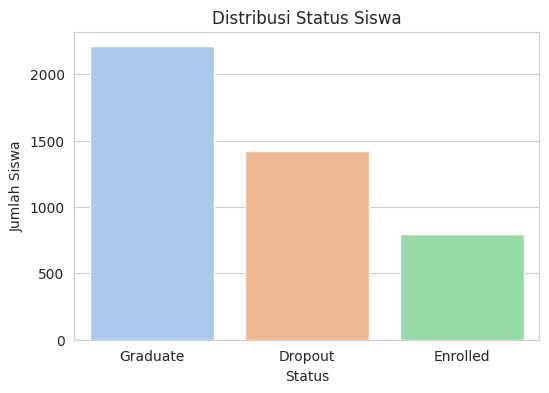

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index, palette='pastel')
plt.title('Distribusi Status Siswa')
plt.xlabel('Status')
plt.ylabel('Jumlah Siswa')
plt.show()

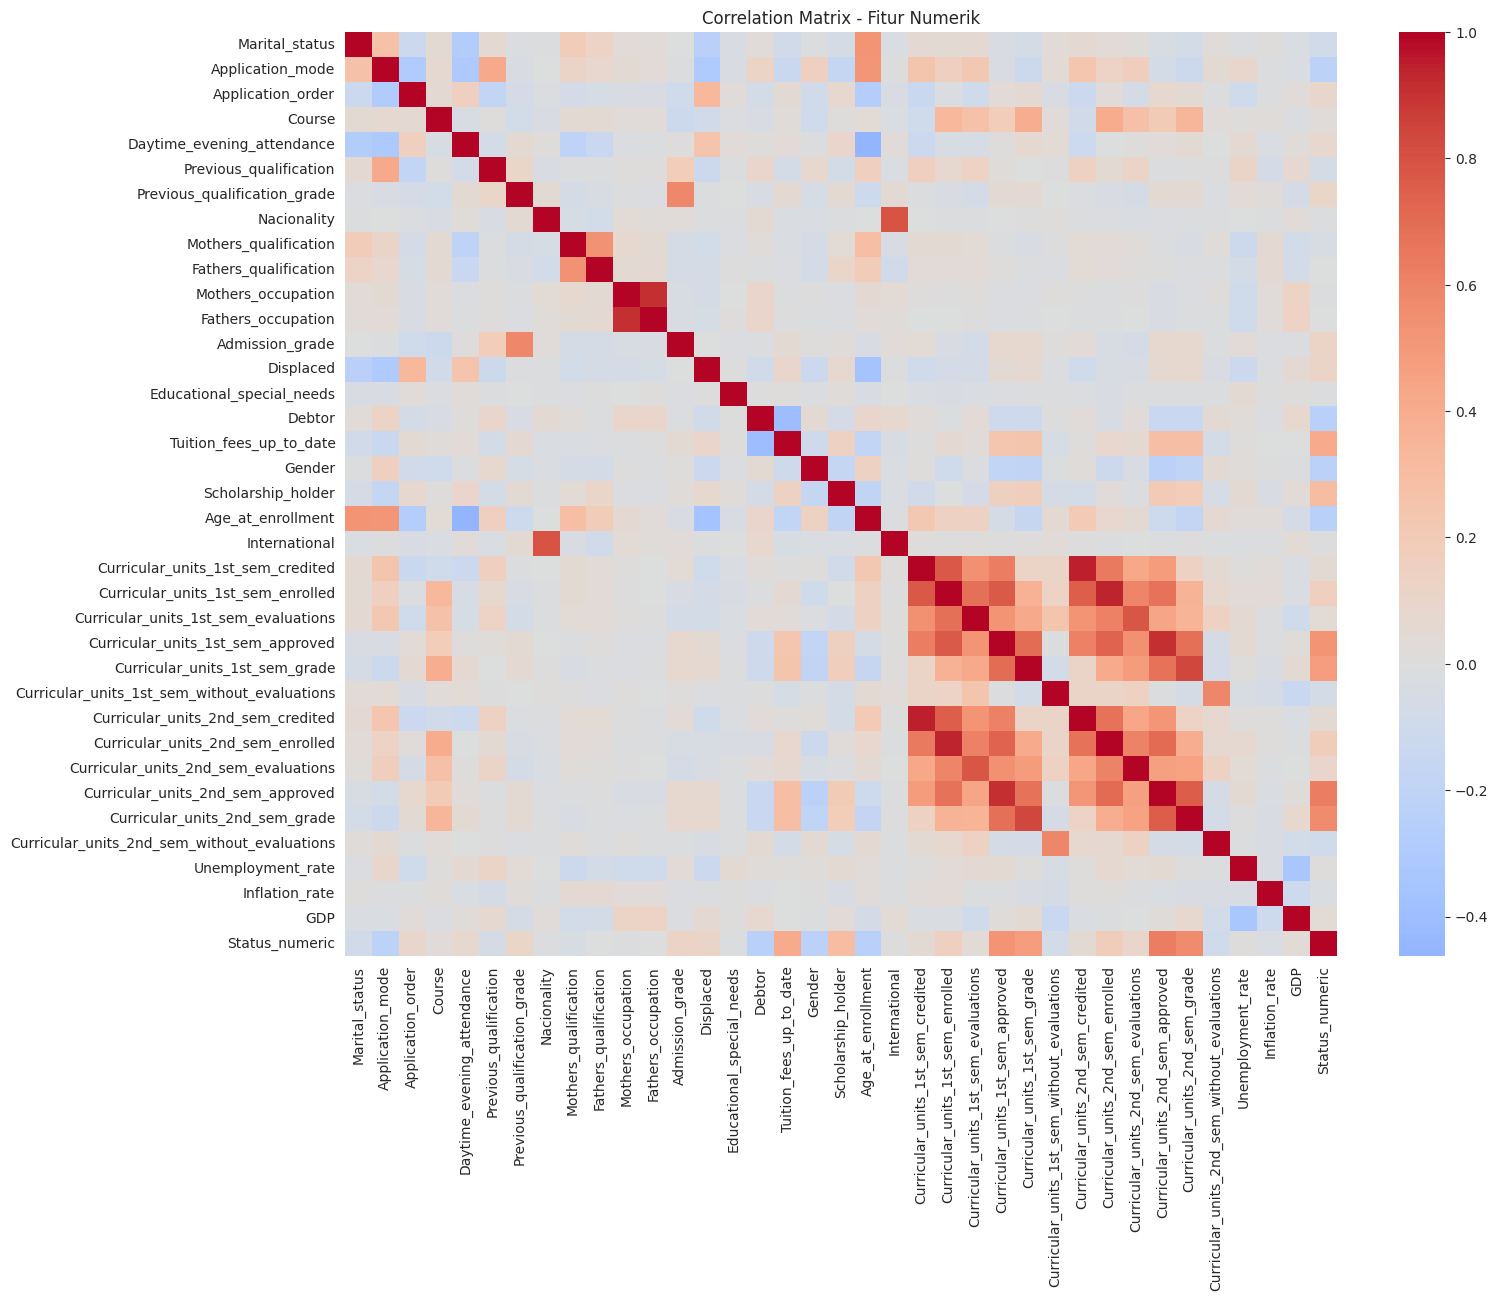

In [9]:
status_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Status_numeric'] = df['Status'].map(status_map)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(16, 12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix - Fitur Numerik')
plt.show()

In [10]:
target_corr = corr['Status_numeric'].drop(['Status_numeric']).sort_values(key=abs, ascending=False)
target_corr.head(10)

,Status_numeric
Curricular_units_2nd_sem_approved,0.624157
Curricular_units_2nd_sem_grade,0.566827
Curricular_units_1st_sem_approved,0.529123
Curricular_units_1st_sem_grade,0.485207
Tuition_fees_up_to_date,0.409827
Scholarship_holder,0.297595
Age_at_enrollment,-0.243438
Debtor,-0.240999
Gender,-0.229270
Application_mode,-0.221747


/tmp/ipykernel_1065/2493889264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_1065/2493889264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_1065/2493889264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_1065/2493889264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

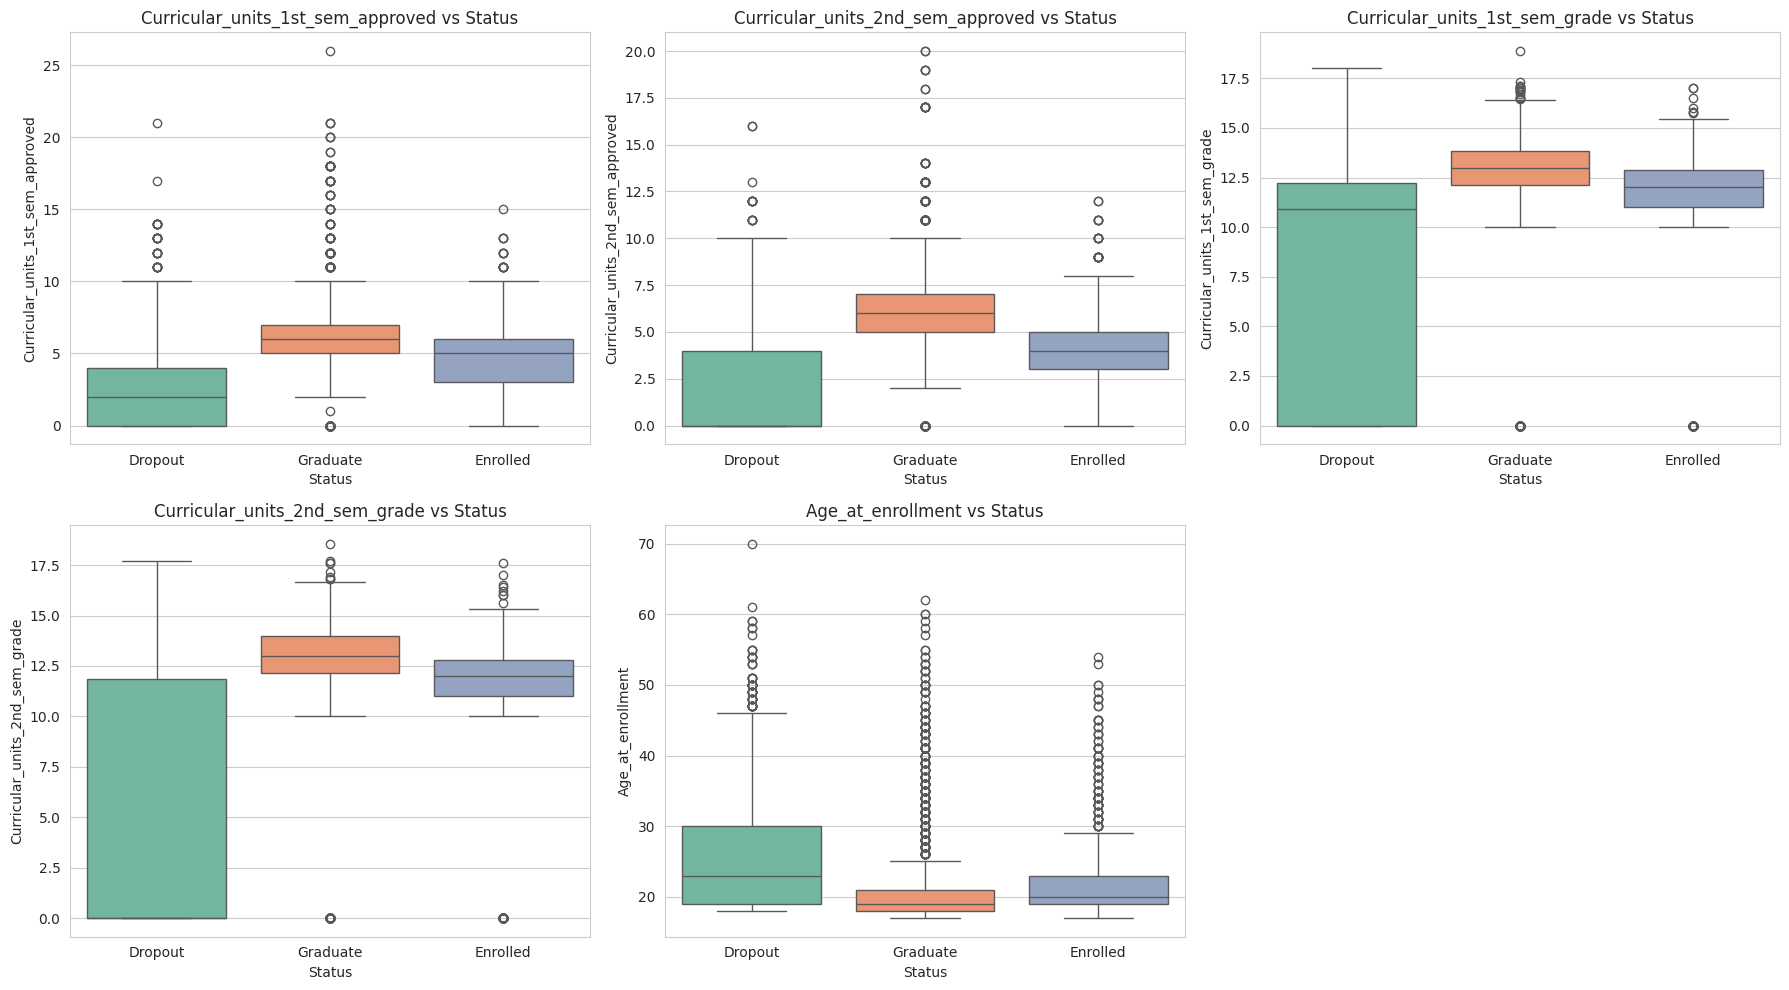

In [11]:
key_features = ['Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
                 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade', 'Age_at_enrollment']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Status', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Status')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

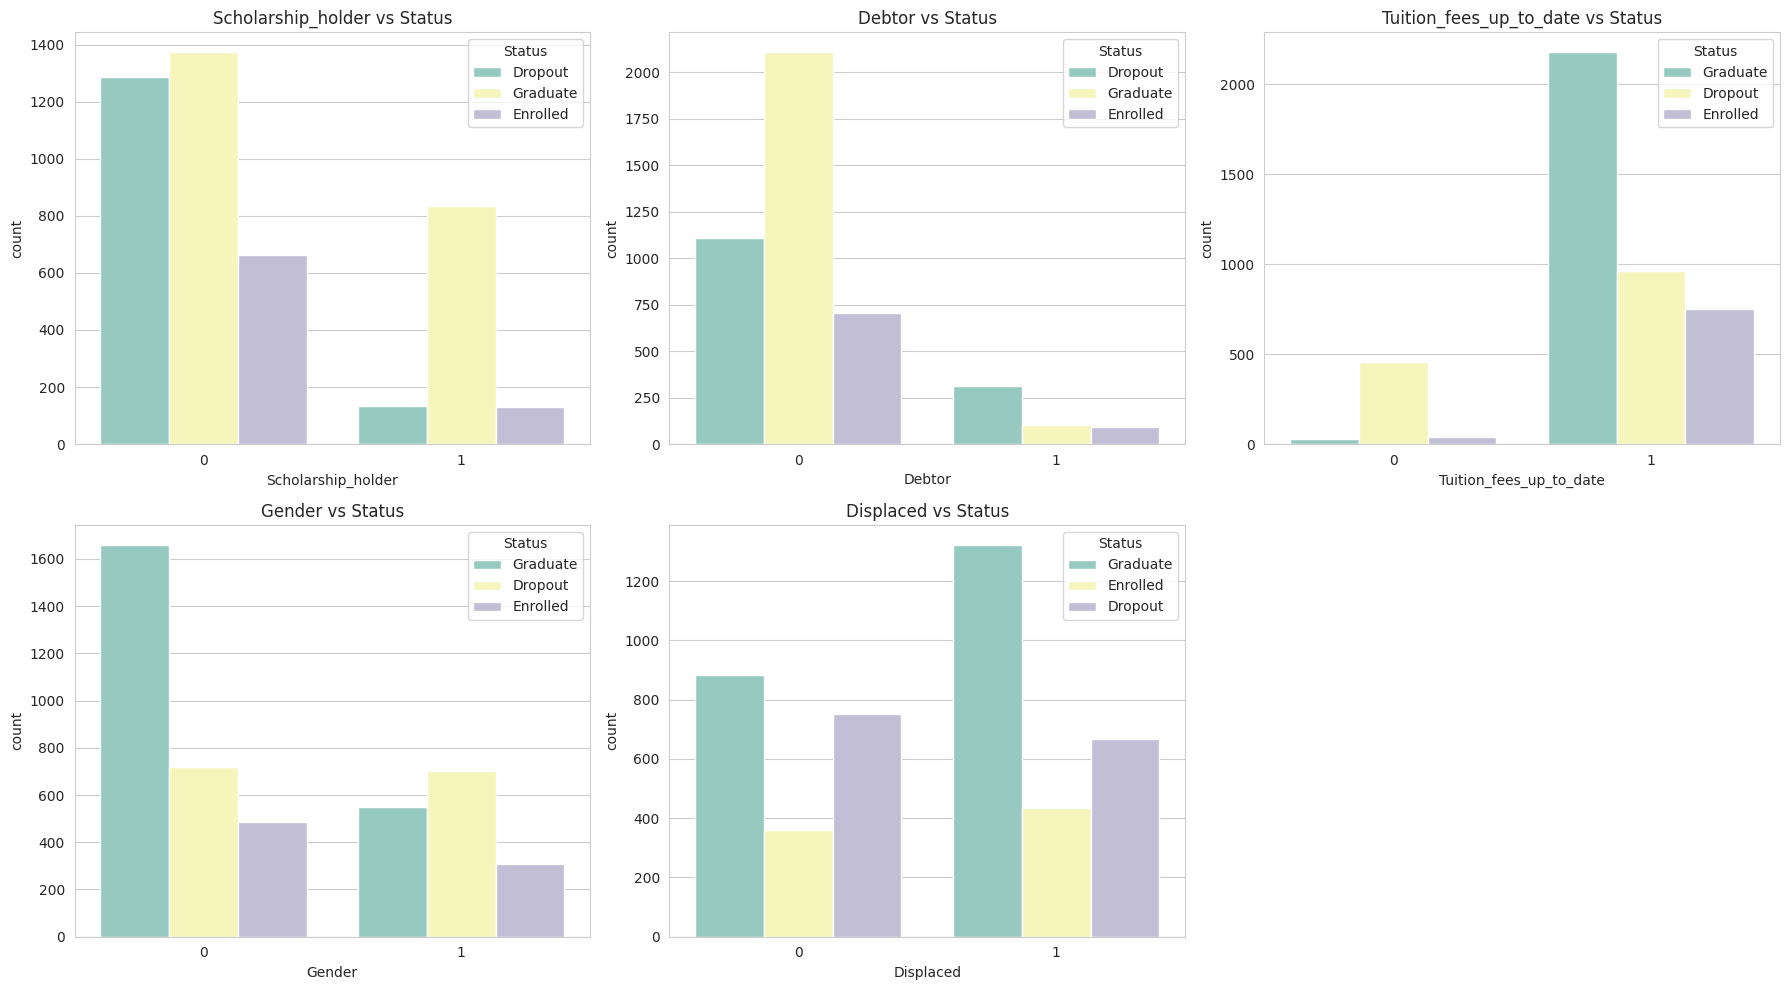

In [12]:
categorical_key = ['Scholarship_holder', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Displaced']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_key):
    sns.countplot(data=df, x=col, hue='Status', ax=axes[i], palette='Set3')
    axes[i].set_title(f'{col} vs Status')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

**Ringkasan EDA:**

Faktor akademik pada semester 1 dan 2 (jumlah mata kuliah yang disetujui/approved dan nilai rata-rata)
merupakan prediktor terkuat terhadap status siswa, dengan korelasi hingga 0.62. Siswa yang gagal
menyelesaikan sebagian besar mata kuliahnya pada semester awal berisiko tinggi untuk dropout.

Faktor finansial juga berperan signifikan: siswa dengan status pembayaran SPP yang tidak up-to-date
dan/atau berstatus debtor jauh lebih rentan mengalami dropout, sementara penerima beasiswa cenderung
lebih protektif terhadap dropout. Usia saat pendaftaran turut berkontribusi — siswa yang mendaftar
pada usia lebih tua menunjukkan kecenderungan dropout yang lebih tinggi.

Insight ini mengindikasikan bahwa performa akademik di semester-semester awal dan kondisi finansial
siswa merupakan sinyal penting yang perlu dipantau sejak dini oleh Jaya Jaya Institut.

## Data Preprocessing

Tahap ini mempersiapkan data agar siap digunakan untuk pemodelan: encoding label target,
split data latih & uji, penanganan imbalance kelas, dan standardisasi fitur numerik.

In [13]:
X = df.drop(columns=['Status', 'Status_numeric'])
y = df['Status']

In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# cek mapping label
dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3539, 36)
Test shape: (885, 36)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Distribusi sebelum SMOTE:", np.bincount(y_train))
print("Distribusi sesudah SMOTE:", np.bincount(y_train_resampled))

Distribusi sebelum SMOTE: [1137  635 1767]
Distribusi sesudah SMOTE: [1767 1767 1767]


## Modeling

Pada tahap ini akan dilatih beberapa algoritma klasifikasi untuk memprediksi status siswa
(Dropout/Enrolled/Graduate): Logistic Regression sebagai baseline linear, dan Random Forest
sebagai model berbasis ensemble yang mampu menangkap hubungan non-linear antar fitur.

In [18]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_resampled, y_train_resampled)

y_pred_log = log_reg.predict(X_test_scaled)

In [19]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test_scaled)

## Evaluation

Pada tahap ini, performa kedua model dibandingkan menggunakan classification report (precision,
recall, f1-score per kelas) dan confusion matrix. Model dengan performa terbaik dan paling seimbang
antar kelas akan dipilih sebagai model final, kemudian dianalisis fitur-fitur yang paling berpengaruh
terhadap prediksinya.

In [20]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log, target_names=label_encoder.classes_))

=== Logistic Regression ===
              precision    recall  f1-score   support

     Dropout       0.85      0.69      0.76       284
    Enrolled       0.42      0.62      0.50       159
    Graduate       0.86      0.80      0.83       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.77      0.74      0.75       885



In [21]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

=== Random Forest ===
              precision    recall  f1-score   support

     Dropout       0.83      0.73      0.77       284
    Enrolled       0.52      0.53      0.52       159
    Graduate       0.83      0.89      0.86       442

    accuracy                           0.77       885
   macro avg       0.73      0.71      0.72       885
weighted avg       0.77      0.77      0.77       885



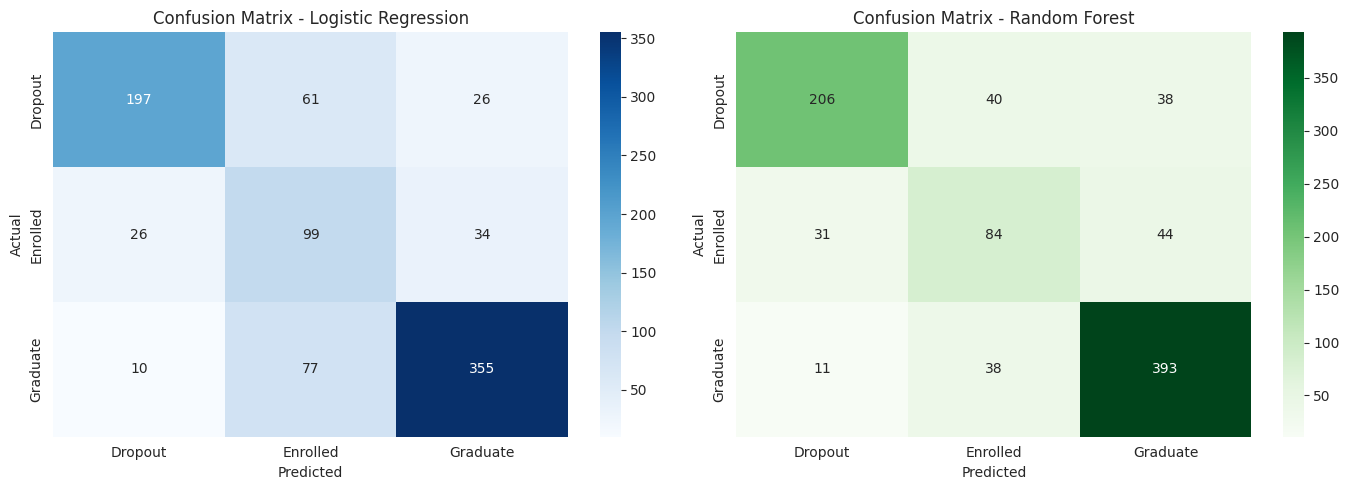

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1065/154775367.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.head(15).values, y=feature_importance.head(15).index, palette='viridis')


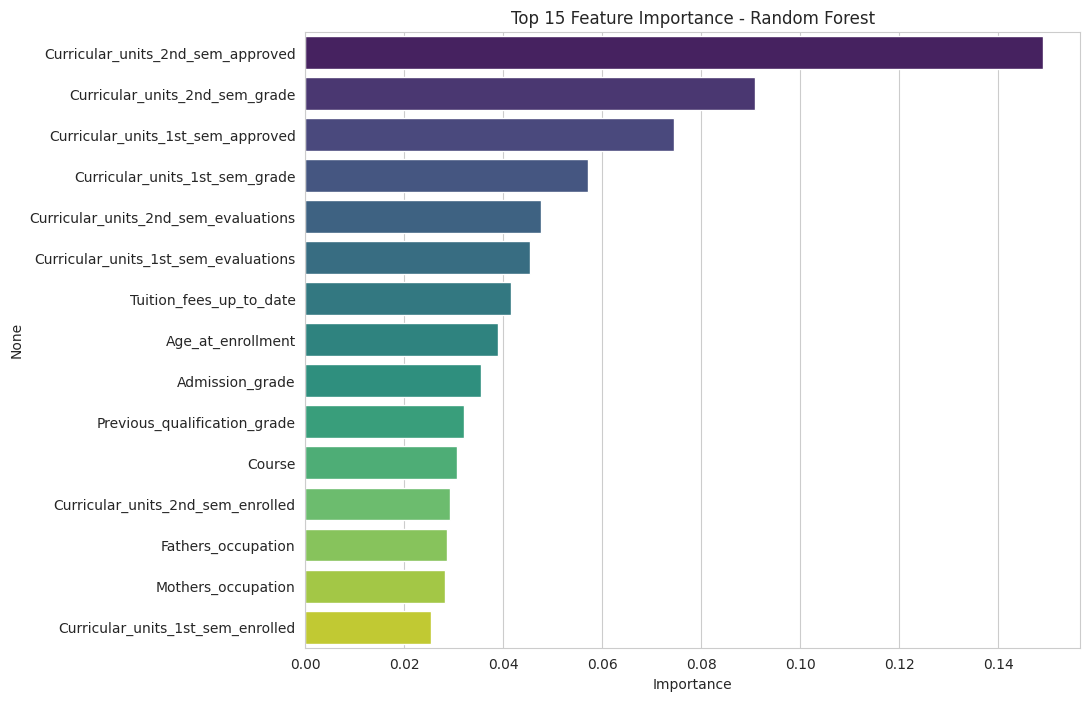

,0
Curricular_units_2nd_sem_approved,0.149138
Curricular_units_2nd_sem_grade,0.090803
Curricular_units_1st_sem_approved,0.074512
Curricular_units_1st_sem_grade,0.057188
Curricular_units_2nd_sem_evaluations,0.047534
Curricular_units_1st_sem_evaluations,0.045400
Tuition_fees_up_to_date,0.041629
Age_at_enrollment,0.038924
Admission_grade,0.035452
Previous_qualification_grade,0.032068


In [23]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance.head(15).values, y=feature_importance.head(15).index, palette='viridis')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()

feature_importance.head(15)

**Ringkasan Evaluation:**

Random Forest menunjukkan performa lebih baik dibanding Logistic Regression di seluruh metrik,
dengan akurasi 77% dan F1-score yang lebih tinggi pada ketiga kelas (Dropout: 0.77, Enrolled: 0.52,
Graduate: 0.86). Oleh karena itu, **Random Forest dipilih sebagai model final**.

Kelas Enrolled tetap menjadi yang paling menantang untuk diprediksi pada kedua model, karena secara
konsep berada di antara Dropout dan Graduate — siswa yang masih aktif namun belum pasti arah
kelulusannya. Feature importance dari Random Forest mengonfirmasi bahwa jumlah mata kuliah yang
disetujui dan nilai pada semester 1 & 2 adalah prediktor terkuat, sejalan dengan temuan pada tahap EDA.

**Export Model**

In [24]:
import os
os.makedirs('model', exist_ok=True)

joblib.dump(rf, 'model/model_rf.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(label_encoder, 'model/label_encoder.pkl')

print("Model, scaler, dan label encoder berhasil disimpan ke folder 'model/'")

Model, scaler, dan label encoder berhasil disimpan ke folder 'model/'


## Conclusion

Proyek ini bertujuan membantu Jaya Jaya Institut mendeteksi siswa yang berisiko dropout sejak dini,
sehingga dapat diberikan bimbingan khusus sebelum terlambat.

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan, dapat disimpulkan:

1. **Model prediksi**: Random Forest berhasil membangun model klasifikasi 3 kelas (Dropout/Enrolled/
   Graduate) dengan akurasi 77%, dan mampu mengidentifikasi siswa berisiko dropout dengan cukup baik
   (F1-score 0.77 untuk kelas Dropout).

2. **Faktor akademik semester awal adalah prediktor terkuat.** Jumlah mata kuliah yang berhasil
   disetujui (approved) dan nilai rata-rata pada semester 1 dan 2 memiliki korelasi tertinggi terhadap
   status siswa. Siswa yang kesulitan menyelesaikan mata kuliahnya di awal masa studi menunjukkan
   risiko dropout yang jauh lebih tinggi.

3. **Faktor finansial berperan signifikan.** Status pembayaran SPP yang tidak up-to-date dan status
   sebagai debtor sangat berkaitan dengan dropout, sementara kepemilikan beasiswa cenderung protektif
   terhadap dropout.

4. **Faktor demografis turut berkontribusi**, khususnya usia saat pendaftaran — siswa yang mendaftar
   pada usia lebih tua menunjukkan kecenderungan dropout yang lebih tinggi dibanding siswa yang lebih muda.

Dengan model dan insight ini, Jaya Jaya Institut memiliki dasar kuat untuk melakukan intervensi dini
kepada siswa yang teridentifikasi berisiko tinggi dropout, alih-alih menunggu hingga siswa benar-benar
keluar dari program studi.

### **Rekomendasi Action Items**

Berdasarkan hasil analisis di atas, berikut rekomendasi action items untuk Jaya Jaya Institut:

1. **Monitoring performa akademik semester 1 secara aktif.** Bangun sistem *early warning* yang
   memantau jumlah mata kuliah yang disetujui setiap siswa pada akhir semester 1 — siswa dengan jumlah
   approved yang rendah harus segera masuk daftar prioritas bimbingan akademik.

2. **Program bimbingan khusus untuk siswa dengan tunggakan SPP.** Karena status pembayaran SPP sangat
   berkorelasi dengan dropout, sebaiknya institusi menyediakan opsi keringanan/cicilan pembayaran serta
   pendampingan finansial bagi siswa yang menunggak, sebelum mereka memutuskan untuk keluar.

3. **Perluas cakupan beasiswa.** Karena penerima beasiswa terbukti lebih protektif terhadap dropout,
   pertimbangkan untuk memperluas kriteria penerima beasiswa, khususnya untuk siswa yang menunjukkan
   performa akademik baik namun memiliki kendala finansial.

4. **Perhatian khusus untuk siswa yang mendaftar di usia lebih tua.** Siswa non-tradisional (usia lebih
   tua saat mendaftar) berisiko lebih tinggi dropout — pertimbangkan program pendampingan/orientasi
   khusus yang disesuaikan dengan kebutuhan kelompok ini (misalnya fleksibilitas jadwal).

5. **Manfaatkan dashboard monitoring** yang telah dibuat untuk memantau performa siswa secara berkala
   (per semester), sehingga pihak akademik dapat mengambil tindakan berbasis data secara proaktif,
   bukan reaktif setelah siswa dropout.

6. **Gunakan model prediksi sebagai alat bantu, bukan pengganti keputusan manusia.** Prediksi model
   sebaiknya digunakan sebagai sinyal awal untuk memicu tindak lanjut personal dari dosen wali/konselor
   akademik, bukan sebagai keputusan otomatis.